# Multiple Linear Regression Project

In this notebook I complete each step of the multiple linear regression project using the diamonds dataset from Seaborn.

## Question 1 - Load the Dataset

First, I load the diamonds dataset into a DataFrame so it can be used throughout the project.

In [19]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SelectKBest, f_regression
import matplotlib.pyplot as plt

data = sns.load_dataset('diamonds')

## Question 2 - Display the First Five Rows

Next, I display the first five rows to make sure the dataset loaded correctly.

In [20]:
print(data.head())

   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75


## Question 3 - Remove Unneeded Columns

The x, y, and z columns are not needed for this project, so I remove them before building the model.

In [21]:
data = data.drop(columns=['x', 'y', 'z'])

## Question 4 - Display the Data Types

Here I use the info() method to check the data types for each column.

In [22]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
dtypes: category(3), float64(3), int64(1)
memory usage: 1.8 MB


## Question 5 - Create Dummy Variables

Since regression models require numeric data, I convert the categorical columns into dummy variables.

In [23]:
dummy_vars = pd.get_dummies(
    data[['cut', 'color', 'clarity']],
    drop_first=True
)

## Question 6 - Join the Dummy Variables

After creating the dummy variables, I remove the original categorical columns and join the new dummy columns to the DataFrame. I also display the updated information to verify the changes.

In [24]:
dataDummies = data.drop(columns=['cut', 'color', 'clarity']).join(dummy_vars)

dataDummies.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   carat          53940 non-null  float64
 1   depth          53940 non-null  float64
 2   table          53940 non-null  float64
 3   price          53940 non-null  int64  
 4   cut_Premium    53940 non-null  bool   
 5   cut_Very Good  53940 non-null  bool   
 6   cut_Good       53940 non-null  bool   
 7   cut_Fair       53940 non-null  bool   
 8   color_E        53940 non-null  bool   
 9   color_F        53940 non-null  bool   
 10  color_G        53940 non-null  bool   
 11  color_H        53940 non-null  bool   
 12  color_I        53940 non-null  bool   
 13  color_J        53940 non-null  bool   
 14  clarity_VVS1   53940 non-null  bool   
 15  clarity_VVS2   53940 non-null  bool   
 16  clarity_VS1    53940 non-null  bool   
 17  clarity_VS2    53940 non-null  bool   
 18  clarity_SI1    53

## Question 7 - Rescale the Numeric Data

Next, I standardize the numeric predictor columns so they are on the same scale before creating the model.

In [25]:
numeric_cols = dataDummies.drop(columns=['price']).select_dtypes(include='number').columns

scaler = StandardScaler()

dataDummies[numeric_cols] = scaler.fit_transform(dataDummies[numeric_cols])

print(dataDummies.head())

      carat     depth     table  price  cut_Premium  cut_Very Good  cut_Good  \
0 -1.198168 -0.174092 -1.099672    326        False          False     False   
1 -1.240361 -1.360738  1.585529    326         True          False     False   
2 -1.198168 -3.385019  3.375663    327        False          False      True   
3 -1.071587  0.454133  0.242928    334         True          False     False   
4 -1.029394  1.082358  0.242928    335        False          False      True   

   cut_Fair  color_E  color_F  ...  color_H  color_I  color_J  clarity_VVS1  \
0     False     True    False  ...    False    False    False         False   
1     False     True    False  ...    False    False    False         False   
2     False     True    False  ...    False    False    False         False   
3     False    False    False  ...    False     True    False         False   
4     False    False    False  ...    False    False     True         False   

   clarity_VVS2  clarity_VS1  clarity_VS2  c

## Question 8 - Display the Correlation with Price

Here I display the correlation values to see which features are most closely related to the price.

In [26]:
correlation = dataDummies.corr()['price'].sort_values(ascending=False)

print(correlation)

price            1.000000
carat            0.921591
clarity_SI2      0.128420
table            0.127134
color_I          0.097125
cut_Premium      0.095706
color_J          0.081710
color_H          0.059223
cut_Fair         0.018728
clarity_SI1      0.008957
color_G          0.008556
cut_Very Good    0.006593
clarity_I1      -0.000255
cut_Good        -0.000312
clarity_VS2     -0.001062
clarity_VS1     -0.009886
depth           -0.010647
color_F         -0.024161
clarity_VVS2    -0.052381
clarity_VVS1    -0.095266
color_E         -0.101089
Name: price, dtype: float64


## Question 9 - Create the Training and Testing Data

Using the five features with the highest correlation to price, I split the data into training and testing datasets. I use a 70/30 split with a random state so the results stay consistent.

In [27]:
top_5_features = correlation.drop('price').abs().nlargest(5).index

X = dataDummies[top_5_features]

y = dataDummies['price']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

## Question 10 - Create and Train the Model

Now I create a linear regression model and fit it using the training data.

In [28]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 3892.94,-1361.2 , -153.6 , 279.66, -732.18]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['carat','clarity_SI2','table','color_E','color_I']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4190
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


## Question 11 - Test Score

After training the model, I calculate the score using the testing dataset to see how well it performs on unseen data.

In [29]:
test_score = model.score(X_test, y_test)

print("Test Score:", test_score)

Test Score: 0.869990765189063


## Question 12 - Training Score

I also calculate the score using the training dataset so I can compare it with the testing score.

In [30]:
train_score = model.score(X_train, y_train)

print("Training Score:", train_score)

Training Score: 0.8695655064391932


## Question 13 - Make Predictions

Next, I use the trained model to predict prices for the testing data.

In [31]:
predictions = model.predict(X_test)

## Question 14 - Compare Actual and Predicted Prices

To compare the results, I create a DataFrame that includes the predictor values along with the actual and predicted prices.

In [32]:
results_df = X_test.copy()

results_df['Actual Price'] = y_test

results_df['Predicted Price'] = predictions

print(results_df.head())

          carat  clarity_SI2     table  color_E  color_I  Actual Price  \
1388  -1.177071        False -0.652139    False    False           559   
50052 -0.459782        False -0.204605    False    False          2201   
41645 -0.839523        False -1.099672     True    False          1238   
42377 -0.776233        False -0.204605     True    False          1304   
17244  1.586602         True -1.099672     True    False          6901   

       Predicted Price  
1388       -292.592913  
50052      2431.031318  
41645      1369.856930  
42377      1478.761912  
17244      9453.420752  


## Question 15 - Calculate the Residuals

The residuals are calculated by subtracting the predicted price from the actual price. This shows how far each prediction is from the true value.

In [33]:
results_df['Residuals'] = (
    results_df['Actual Price']
    - results_df['Predicted Price']
)

print(results_df.head())

          carat  clarity_SI2     table  color_E  color_I  Actual Price  \
1388  -1.177071        False -0.652139    False    False           559   
50052 -0.459782        False -0.204605    False    False          2201   
41645 -0.839523        False -1.099672     True    False          1238   
42377 -0.776233        False -0.204605     True    False          1304   
17244  1.586602         True -1.099672     True    False          6901   

       Predicted Price    Residuals  
1388       -292.592913   851.592913  
50052      2431.031318  -230.031318  
41645      1369.856930  -131.856930  
42377      1478.761912  -174.761912  
17244      9453.420752 -2552.420752  


## Question 16 - Plot the Residuals

Here I create a KDE plot to visualize the distribution of the residual values.

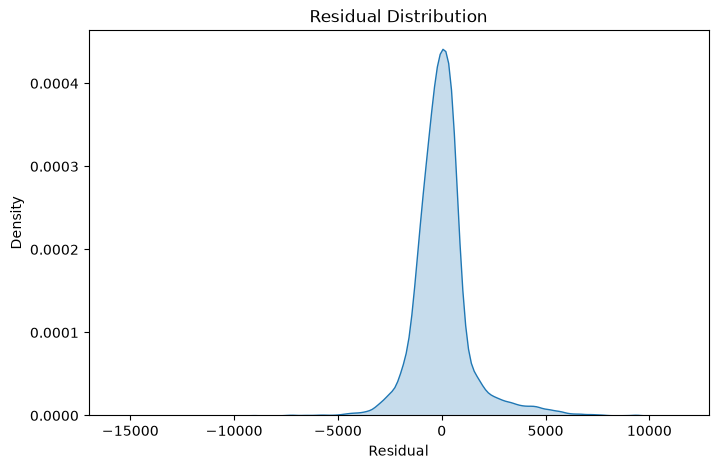

In [34]:
plt.figure(figsize=(8,5))

sns.kdeplot(results_df['Residuals'], fill=True)

plt.title("Residual Distribution")

plt.xlabel("Residual")

plt.show()

## Question 17 - Test Different Numbers of Features

In this step, I use SelectKBest inside a loop to test different numbers of features. I record both the training and testing scores for each model.

In [35]:
X_all = dataDummies.drop('price', axis=1)

y_all = dataDummies['price']

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all,
    y_all,
    test_size=0.30,
    random_state=42
)

train_scores = []

test_scores = []

num_features_list = range(1, len(X_all.columns) + 1)

for k in num_features_list:

    selector = SelectKBest(score_func=f_regression, k=k)

    X_train_k = selector.fit_transform(X_train_all, y_train_all)

    X_test_k = selector.transform(X_test_all)

    temp_model = LinearRegression()

    temp_model.fit(X_train_k, y_train_all)

    train_scores.append(
        temp_model.score(X_train_k, y_train_all)
    )

    test_scores.append(
        temp_model.score(X_test_k, y_test_all)
    )

## Question 18 - Plot the Scores

Finally, I plot the training and testing scores against the number of selected features to compare how the model performs as more features are added.

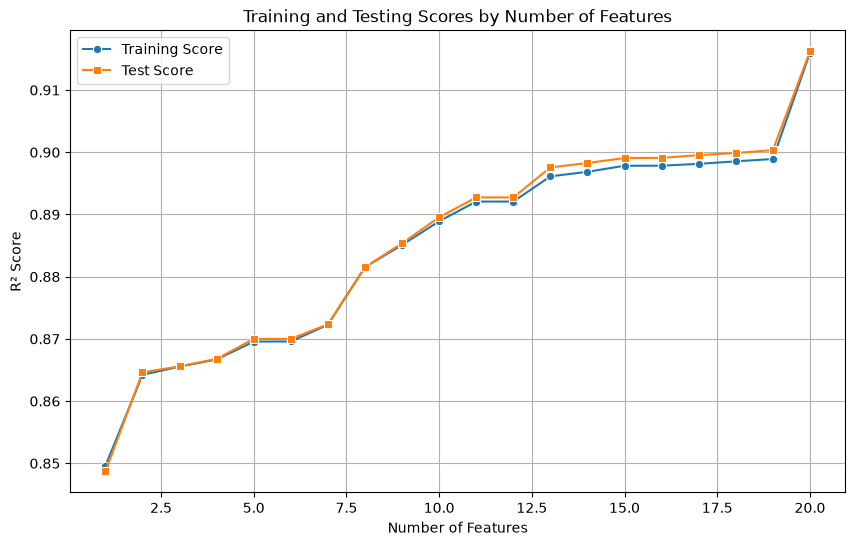

In [36]:
plt.figure(figsize=(10,6))

sns.lineplot(
    x=list(num_features_list),
    y=train_scores,
    marker='o',
    label='Training Score'
)

sns.lineplot(
    x=list(num_features_list),
    y=test_scores,
    marker='s',
    label='Test Score'
)

plt.title("Training and Testing Scores by Number of Features")

plt.xlabel("Number of Features")

plt.ylabel("R² Score")

plt.grid(True)

plt.legend()

plt.show()